# Project 02 – Customer Behavior Analysis


### Setup & Verification

Loading the cleaned dataset from Project 01 and verifying that all columns, 
data types, and value integrity carried over correctly before starting Project 02 analysis.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

FILE_PATH = Path("cleaned_dataset_aliaghilii.xlsx")

if not FILE_PATH.exists():
    raise FileNotFoundError(f"File not found: {FILE_PATH}")

df = pd.read_excel(FILE_PATH, sheet_name="Sheet1")

print(f"✅ Dataset loaded successfully: {df.shape[0]} rows, {df.shape[1]} columns")

✅ Dataset loaded successfully: 60 rows, 18 columns


### Check 1: Required Columns

In [7]:
required_columns = [
    "customer_id", "first_name", "gender", "gender_inferred", "age",
    "province", "city", "membership_tier", "device", "payment_method",
    "signup_date", "total_spending", "purchase_count", "avg_order_value",
    "discount_used", "returned_items", "last_purchase_days", "satisfaction_score"
]

missing_columns = [col for col in required_columns if col not in df.columns]

if missing_columns:
    print(f"⚠️ Missing columns: {missing_columns}")
else:
    print("✅ All required columns are present.")

✅ All required columns are present.


### Check 2: Data Types

In [10]:
print(df.dtypes)

customer_id                    int64
first_name                    object
gender                        object
age                            int64
city                          object
province                      object
signup_date           datetime64[ns]
membership_tier               object
purchase_count                 int64
avg_order_value              float64
total_spending               float64
last_purchase_days             int64
payment_method                object
device                        object
discount_used                 object
returned_items                 int64
satisfaction_score             int64
gender_inferred               object
dtype: object


### Check 3: Missing Values

In [13]:
print(df.isna().sum())

customer_id           0
first_name            0
gender                0
age                   0
city                  0
province              0
signup_date           0
membership_tier       0
purchase_count        0
avg_order_value       0
total_spending        0
last_purchase_days    0
payment_method        0
device                0
discount_used         0
returned_items        0
satisfaction_score    0
gender_inferred       0
dtype: int64


### Question 1: Who Are Our Core Customers?

Analyzing age groups, inferred gender, membership tier, device, and payment method 
to define the store's dominant customer persona.

Note: `gender_inferred` is used instead of the raw `gender` column, since Project 01 
documented the raw column as unreliable.

In [16]:
bins = [0, 18, 25, 35, 45, 55, 65, 100]
labels = ["<18", "18-25", "26-35", "36-45", "46-55", "56-65", "65+"]

df["age_group"] = pd.cut(df["age"], bins=bins, labels=labels, right=True)

print(df["age_group"].value_counts().sort_index())

age_group
<18       0
18-25    10
26-35     9
36-45    13
46-55    11
56-65    17
65+       0
Name: count, dtype: int64


In [18]:
print(f"Mean age: {df['age'].mean():.1f}")
print(f"Median age: {df['age'].median():.1f}")
print(f"Most common age group: {df['age_group'].mode()[0]}")

Mean age: 43.7
Median age: 45.0
Most common age group: 56-65


In [20]:
print("Gender (inferred):")
print(df["gender_inferred"].value_counts())
print("\nMembership Tier:")
print(df["membership_tier"].value_counts())
print("\nDevice:")
print(df["device"].value_counts())
print("\nPayment Method:")
print(df["payment_method"].value_counts())

Gender (inferred):
gender_inferred
M    35
F    25
Name: count, dtype: int64

Membership Tier:
membership_tier
Gold      19
Bronze    18
VIP       15
Silver     8
Name: count, dtype: int64

Device:
device
Android    22
Web        20
iPhone     18
Name: count, dtype: int64

Payment Method:
payment_method
Online Wallet    23
Cash             19
Card             18
Name: count, dtype: int64


### Question 1: Summary Table of Dominant Customer Characteristics

In [23]:
summary_table = pd.DataFrame({
    "Attribute": ["Age (mean)", "Age (median)", "Most Common Age Group",
                  "Dominant Gender (inferred)", "Most Common Membership Tier",
                  "Most Common Device", "Most Common Payment Method"],
    "Value": [
        f"{df['age'].mean():.1f}",
        f"{df['age'].median():.1f}",
        df["age_group"].mode()[0],
        df["gender_inferred"].mode()[0],
        df["membership_tier"].mode()[0],
        df["device"].mode()[0],
        df["payment_method"].mode()[0]
    ]
})

summary_table

,Attribute,Value
0,Age (mean),43.7
1,Age (median),45.0
2,Most Common Age Group,56-65
3,Dominant Gender (inferred),M
4,Most Common Membership Tier,Gold
5,Most Common Device,Android
6,Most Common Payment Method,Online Wallet


### Question 1: Visualizations

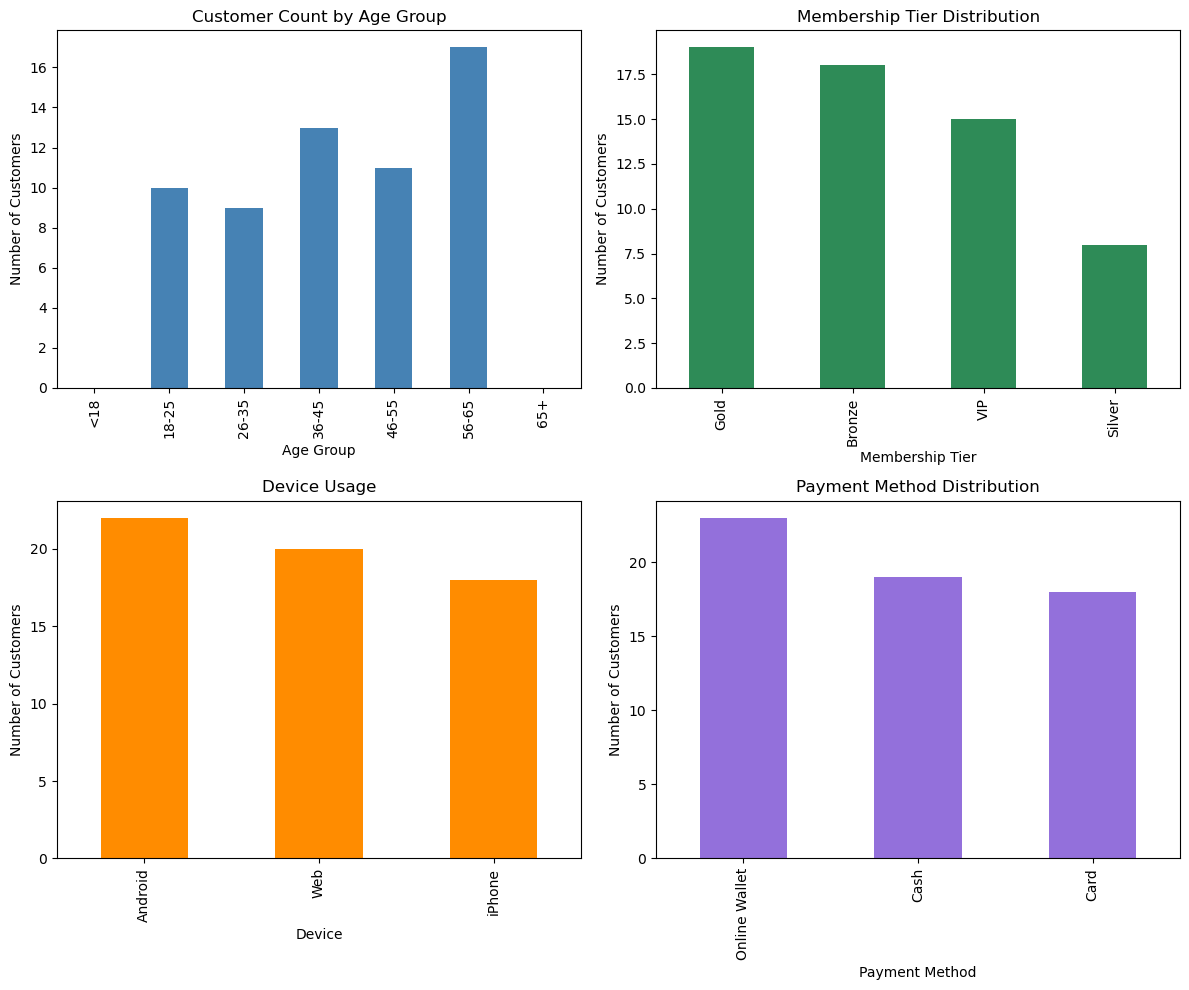

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

df["age_group"].value_counts().sort_index().plot(kind="bar", ax=axes[0,0], color="steelblue")
axes[0,0].set_title("Customer Count by Age Group")
axes[0,0].set_xlabel("Age Group")
axes[0,0].set_ylabel("Number of Customers")

df["membership_tier"].value_counts().plot(kind="bar", ax=axes[0,1], color="seagreen")
axes[0,1].set_title("Membership Tier Distribution")
axes[0,1].set_xlabel("Membership Tier")
axes[0,1].set_ylabel("Number of Customers")

df["device"].value_counts().plot(kind="bar", ax=axes[1,0], color="darkorange")
axes[1,0].set_title("Device Usage")
axes[1,0].set_xlabel("Device")
axes[1,0].set_ylabel("Number of Customers")

df["payment_method"].value_counts().plot(kind="bar", ax=axes[1,1], color="mediumpurple")
axes[1,1].set_title("Payment Method Distribution")
axes[1,1].set_xlabel("Payment Method")
axes[1,1].set_ylabel("Number of Customers")

plt.tight_layout()
plt.savefig("charts/q1_customer_persona.png", dpi=150)
plt.show()

**Customer Persona Summary:**

Based on the available data, the store's dominant customer is a middle-aged to 
older male (mean age 43.7, with a notable concentration in the 56–65 age group) 
holding a Gold or Bronze membership tier. This customer primarily shops via 
Android devices and prefers Online Wallet as the payment method. However, it's 
important to note that this represents a **dominant tendency rather than a 
strong majority**: gender distribution (58% vs. 42%), membership tiers, and 
device usage are all relatively balanced. With a sample size of only 60 
customers, these patterns should be interpreted with statistical caution.
Whether marketing efforts should focus on this dominant persona or instead 
target a smaller, higher-value customer segment cannot be determined from 
demographic data alone — this will be examined in Question 3 (loyalty program) 
and Question 2 (city/regional value), where spending and engagement metrics 
are analyzed directly.

### Question 2: Which Province/City Deserves Marketing Investment?

Grouping customers by province + city combination to avoid merging cities with 
the same name across different provinces. Cities with fewer than 3 customers 
are excluded from the primary ranking, since averages from very small samples 
are unstable.

In [29]:
city_stats = df.groupby(["province", "city"]).agg(
    customer_count=("customer_id", "nunique"),
    total_revenue=("total_spending", "sum"),
    avg_spending=("total_spending", "mean"),
    avg_satisfaction=("satisfaction_score", "mean")
).reset_index()

city_stats_filtered = city_stats[city_stats["customer_count"] >= 3].copy()

print(f"Total city/province combinations: {len(city_stats)}")
print(f"After filtering (customer_count >= 3): {len(city_stats_filtered)}")

city_stats_filtered.sort_values("total_revenue", ascending=False)

Total city/province combinations: 8
After filtering (customer_count >= 3): 8


,province,city,customer_count,total_revenue,avg_spending,avg_satisfaction
5,Khorasan,Mashhad,11,43197.58,3927.052727,2.909091
1,East Azerbaijan,Tabriz,12,36192.49,3016.040833,3.000000
0,Alborz,Karaj,7,26189.81,3741.401429,2.857143
6,Khuzestan,Ahvaz,8,24467.17,3058.396250,3.500000
4,Isfahan,Isfahan,5,21975.32,4395.064000,4.400000
2,Fars,Shiraz,6,20715.92,3452.653333,2.000000
3,Gilan,Rasht,5,15168.54,3033.708000,2.600000
7,Tehran,Tehran,6,15161.29,2526.881667,2.666667


### Question 2: Visualizations

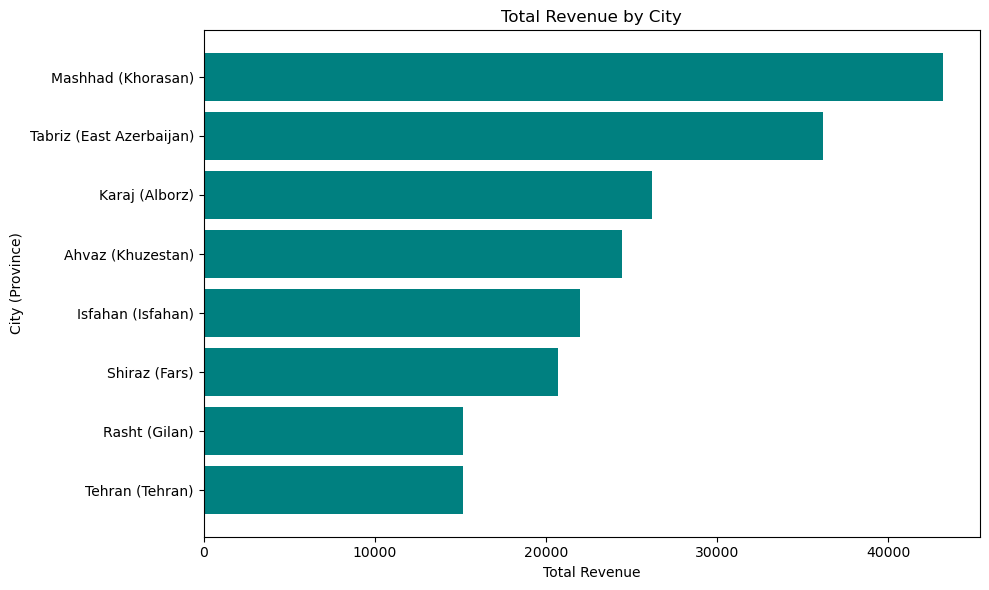

In [31]:
top_cities = city_stats_filtered.sort_values("total_revenue", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(top_cities["city"] + " (" + top_cities["province"] + ")", 
         top_cities["total_revenue"], color="teal")
plt.title("Total Revenue by City")
plt.xlabel("Total Revenue")
plt.ylabel("City (Province)")
plt.tight_layout()
plt.savefig("charts/q2_city_revenue.png", dpi=150)
plt.show()

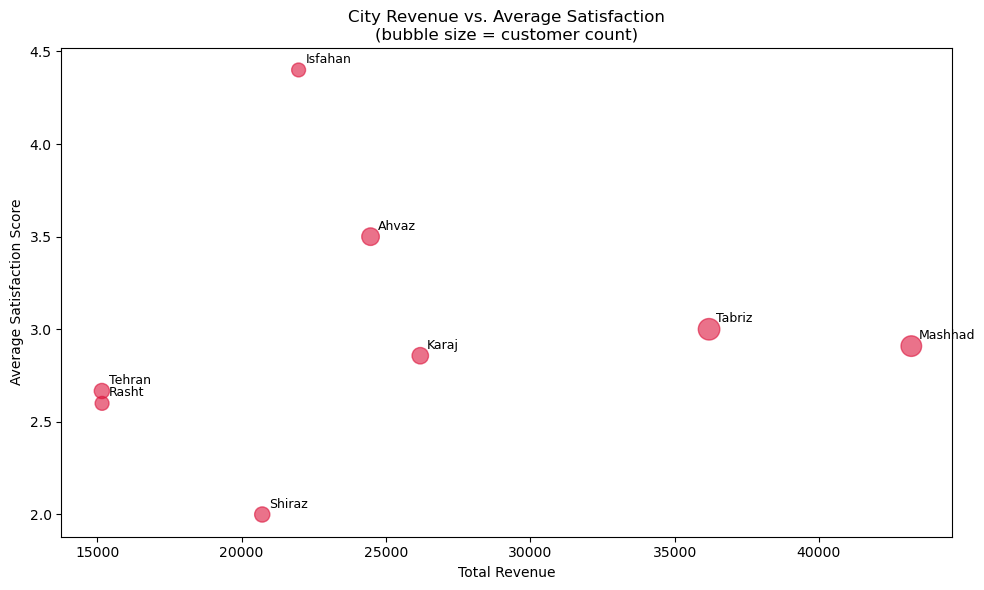

In [35]:
plt.figure(figsize=(10, 6))
plt.scatter(city_stats_filtered["total_revenue"], 
            city_stats_filtered["avg_satisfaction"],
            s=city_stats_filtered["customer_count"] * 20,
            alpha=0.6, color="crimson")

for _, row in city_stats_filtered.iterrows():
    plt.annotate(row["city"], (row["total_revenue"], row["avg_satisfaction"]),
                 textcoords="offset points", xytext=(5, 5), fontsize=9)

plt.title("City Revenue vs. Average Satisfaction\n(bubble size = customer count)")
plt.xlabel("Total Revenue")
plt.ylabel("Average Satisfaction Score")
plt.tight_layout()
plt.savefig("charts/q2_revenue_vs_satisfaction.png", dpi=150)
plt.show()

### Question 2: City Recommendation

In [38]:
final_ranking = city_stats_filtered.sort_values(
    ["total_revenue", "avg_satisfaction", "customer_count"], 
    ascending=[False, False, False]
).reset_index(drop=True)

final_ranking

,province,city,customer_count,total_revenue,avg_spending,avg_satisfaction
0,Khorasan,Mashhad,11,43197.58,3927.052727,2.909091
1,East Azerbaijan,Tabriz,12,36192.49,3016.040833,3.000000
2,Alborz,Karaj,7,26189.81,3741.401429,2.857143
3,Khuzestan,Ahvaz,8,24467.17,3058.396250,3.500000
4,Isfahan,Isfahan,5,21975.32,4395.064000,4.400000
5,Fars,Shiraz,6,20715.92,3452.653333,2.000000
6,Gilan,Rasht,5,15168.54,3033.708000,2.600000
7,Tehran,Tehran,6,15161.29,2526.881667,2.666667


**Quick comparison of top candidates:**

| City | Revenue | Customers | Satisfaction | Summary |
|------|---------|-----------|---------------|---------|
| Mashhad | Highest (43,198) | High (11) | Low (2.91) | High volume, satisfaction risk |
| Tabriz | 2nd highest (36,192) | Highest (12) | Moderate (3.0) | High volume, mediocre satisfaction |
| Isfahan | Low (21,975) | Low (5) | Highest (4.4) | High quality, small scale |
| Ahvaz | Moderate (24,467) | Moderate (8) | 2nd highest (3.5) | Balanced across all metrics |

**City Recommendation:**

**Primary recommendation: Mashhad.** It leads on two of the three key metrics — 
highest total revenue (43,198) and second-highest customer count (11) — making 
it the strongest candidate for scale. However, its average satisfaction score 
(2.91) is among the lowest in the dataset, which is a meaningful risk: 
investing ad budget in a city with low satisfaction may not translate into 
long-term customer retention. This risk should be paired with a parallel effort 
to investigate satisfaction drivers in Mashhad before scaling the campaign further.

**Alternative recommendation: Ahvaz.** While its revenue (24,467) and customer 
count (8) are more modest, it offers a more balanced profile: solid revenue, a 
reasonable customer base, and the second-highest satisfaction score (3.5) among 
cities with sufficient sample size. This makes Ahvaz a lower-risk option if the 
priority is sustainable growth rather than maximum short-term reach.

**Why not Isfahan?** Isfahan has the highest satisfaction (4.4) and highest 
average spending per customer (4,395), suggesting a highly loyal, high-value 
segment — but its small customer count (5) makes it a weaker fit for a 
broad advertising campaign, though it may be worth a smaller, targeted 
retention-focused investment.

### Question 3: Top 10 Customers for Loyalty Program

Combining financial value, purchase frequency, recency, and satisfaction into 
a single weighted loyalty score. Weights: 35% value, 30% frequency, 20% recency, 
15% satisfaction  chosen to prioritize financial contribution and repeat 
engagement over simple recency or satisfaction alone. These weights are an 
analytical assumption and could be adjusted based on business priorities.

In [46]:
def normalize(series):
    minimum, maximum = series.min(), series.max()
    if maximum == minimum:
        return pd.Series(0.5, index=series.index)  
    return (series - minimum) / (maximum - minimum)

In [48]:
df["value_score"] = normalize(df["total_spending"])
df["frequency_score"] = normalize(df["purchase_count"])
df["recency_score"] = 1 - normalize(df["last_purchase_days"])  
df["satisfaction_norm"] = normalize(df["satisfaction_score"])

df["loyalty_score"] = (
    0.35 * df["value_score"] +
    0.30 * df["frequency_score"] +
    0.20 * df["recency_score"] +
    0.15 * df["satisfaction_norm"]
)

top10 = df.nlargest(10, "loyalty_score")[
    ["customer_id", "first_name", "membership_tier", "total_spending",
     "purchase_count", "last_purchase_days", "satisfaction_score", "loyalty_score"]
]

top10

,customer_id,first_name,membership_tier,total_spending,purchase_count,last_purchase_days,satisfaction_score,loyalty_score
56,1057,Maryam,Bronze,13532.74,31,82,4,0.863141
43,1044,Mina,Gold,14354.34,33,165,2,0.780350
58,1059,Ali,Gold,8898.55,31,224,5,0.707020
8,1009,Kimia,Silver,11615.42,34,232,2,0.684090
3,1004,Sina,Gold,6121.45,23,40,4,0.631573
11,1012,Arash,Gold,11731.50,27,224,2,0.629630
32,1033,Neda,VIP,5521.20,24,112,5,0.623200
13,1014,Reza,VIP,3353.89,31,97,4,0.601890
22,1023,Ali,Bronze,3851.44,31,170,4,0.573924
16,1017,Parsa,VIP,3239.40,30,135,4,0.569227


### Question 3: Visualization

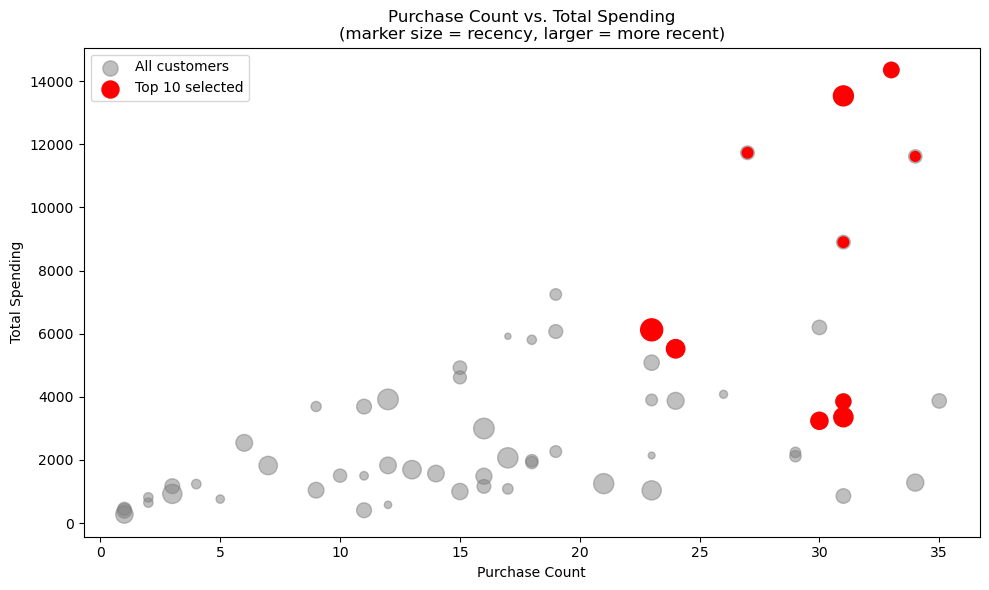

In [67]:
plt.figure(figsize=(10, 6))
plt.scatter(df["purchase_count"], df["total_spending"], 
            s=(1 - normalize(df["last_purchase_days"])) * 200 + 20,
            alpha=0.5, color="gray", label="All customers")
plt.scatter(top10["purchase_count"], top10["total_spending"],
            s=(1 - normalize(top10["last_purchase_days"])) * 200 + 50,
             color="red", edgecolor="red", label="Top 10 selected")
plt.title("Purchase Count vs. Total Spending\n(marker size = recency, larger = more recent)")
plt.xlabel("Purchase Count")
plt.ylabel("Total Spending")
plt.legend()
plt.tight_layout()
plt.savefig("charts/q3_loyalty_top10.png", dpi=150)
plt.show()

**Loyalty Program Selection — Summary:**

**Weighting logic:** The loyalty score combines four dimensions — financial 
value (35%), purchase frequency (30%), recency (20%), and satisfaction (15%). 
Value and frequency were given the highest weights because they most directly 
reflect a customer's business contribution, while recency and satisfaction were 
weighted lower since they indicate engagement quality rather than direct revenue 
impact. These weights are an analytical assumption, not a fixed rule, and could 
be revisited depending on business priorities (e.g., a retention-focused 
campaign might weight recency higher).

**Reason for each selection:**
- Maryam — highest overall score; strong across nearly all dimensions (high 
  spending, high frequency, very recent purchase)
- Mina — highest total spending in the group, despite a less recent purchase 
  and low satisfaction
- Ali (#1059) — high satisfaction (5) and strong frequency, moderate spending
- Kimia — highest purchase frequency (34) in the entire dataset
- Sina — very recent purchase and high satisfaction, despite lower frequency
- Arash — solid, balanced scores across spending and frequency
- Neda — highest possible satisfaction (5), moderate spending and frequency
- Reza — high satisfaction and good recency, lower spending
- Ali (#1023) — balanced mid-range scores across all four dimensions
- Parsa — consistent moderate performance across all metrics, no weak spot

**Do top customers have both high purchase count and high spending?** 
Not consistently. Some (e.g., Mina, Arash) rank high mainly due to spending 
despite average frequency, while others (e.g., Kimia, who has the highest 
frequency in the whole dataset) were expected near the top but were **not** 
selected — because her spending and recency scores pulled her overall score 
down. This confirms the weighted approach avoids simply rewarding one 
dimension (like raw purchase count) in isolation.

**Should a high-spend but very inactive customer still get a reward?** 
Mina illustrates this exactly: she has the highest total spending in the group 
but hasn't purchased in 165 days and reports low satisfaction (2/5). She was 
still selected because value carries the highest weight (35%) — but this is a 
judgment call, not an obvious answer. A more retention-cautious version of 
this program might down-weight value and up-weight recency, which would likely 
drop her from the top 10 in favor of a more recently active customer.

**Is current membership tier consistent with the calculated score?** 
No — this is one of the clearest findings. Maryam, the #1 loyalty customer, 
holds only a **Bronze** tier, the lowest available level. Meanwhile, some Gold 
and VIP customers score lower overall. This suggests the current membership 
tier system does not fully reflect actual customer value and engagement, and 
may be worth revisiting independently of this loyalty selection.

**Other anomalies:** Kimia (highest purchase frequency in the dataset) and 
Neda (highest possible satisfaction score) were both expected to appear near 
the top based on a single strong metric, but neither made the top 10 once all 
four dimensions were combined — a reminder that no single metric alone 
identifies the most valuable customers.

### Question 4: Valuable Customers at Risk of Churning

A customer is flagged "at risk" only if all three conditions hold simultaneously: 
high past value (top 25% of total_spending), long inactivity (top 25% of 
last_purchase_days), and purchase frequency at or below the dataset median — 
i.e., they used to be valuable but have gone quiet.

In [71]:
spending_threshold = df["total_spending"].quantile(0.75)
inactivity_threshold = df["last_purchase_days"].quantile(0.75)
frequency_median = df["purchase_count"].median()

print(f"Spending threshold (75th percentile): {spending_threshold:.2f}")
print(f"Inactivity threshold (75th percentile): {inactivity_threshold:.1f} days")
print(f"Frequency median: {frequency_median:.1f}")

df["at_risk"] = (
    (df["total_spending"] >= spending_threshold) &
    (df["last_purchase_days"] >= inactivity_threshold) &
    (df["purchase_count"] <= frequency_median)
)

at_risk_customers = df.loc[df["at_risk"], 
    ["customer_id", "first_name", "total_spending", "purchase_count",
     "last_purchase_days", "membership_tier", "satisfaction_score"]
].sort_values("total_spending", ascending=False)

print(f"\nNumber of at-risk customers: {len(at_risk_customers)}")
at_risk_customers

Spending threshold (75th percentile): 4213.12
Inactivity threshold (75th percentile): 273.8 days
Frequency median: 17.0

Number of at-risk customers: 1


,customer_id,first_name,total_spending,purchase_count,last_purchase_days,membership_tier,satisfaction_score
34,1035,Arash,5918.21,17,365,Bronze,3


### Question 4: Visualization

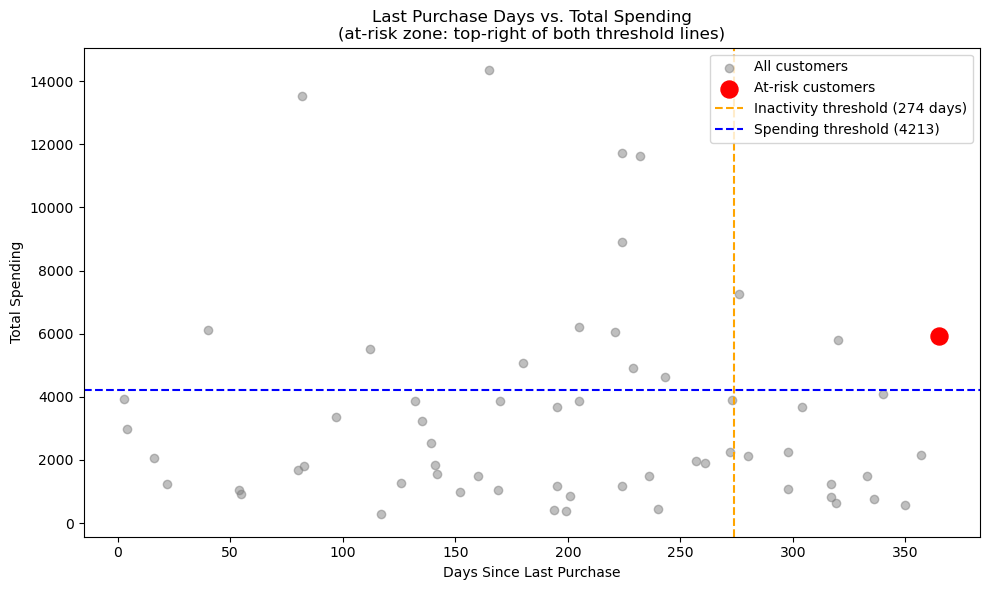

In [76]:
plt.figure(figsize=(10, 6))
plt.scatter(df["last_purchase_days"], df["total_spending"], 
            alpha=0.5, color="gray", label="All customers")
plt.scatter(at_risk_customers["last_purchase_days"], at_risk_customers["total_spending"],
            color="red", s=150,  label="At-risk customers")

plt.axvline(inactivity_threshold, color="orange", linestyle="--", 
            label=f"Inactivity threshold ({inactivity_threshold:.0f} days)")
plt.axhline(spending_threshold, color="blue", linestyle="--", 
            label=f"Spending threshold ({spending_threshold:.0f})")

plt.title("Last Purchase Days vs. Total Spending\n(at-risk zone: top-right of both threshold lines)")
plt.xlabel("Days Since Last Purchase")
plt.ylabel("Total Spending")
plt.legend()
plt.tight_layout()
plt.savefig("charts/q4_at_risk_customers.png", dpi=150)
plt.show()

## Question 4: Valuable Customers at Risk of Churning

### Data-Driven Definition of "Valuable At-Risk Customer"

In this analysis, a customer is flagged as **"valuable and at risk"** only if all **three** of the following conditions are met simultaneously:

1. **High Financial Value:** Total spending is in the **top 25%** of all customers (i.e., `>= 4,213.12` IRR).
2. **Long Inactivity:** Days since last purchase are in the **top 25%** of all customers (i.e., `>= 274` days).
3. **Low Purchase Frequency:** Total purchase count is **less than or equal to the median** purchase count (i.e., `<= 17` purchases).

This definition ensures that:
- Customers who are merely inactive but not valuable are **excluded**
- Customers who are valuable but recently active are **excluded**
- Only customers who were once highly valuable but have gone quiet are flagged

---

### Number of Customers in the Upper-Right Zone (High Value + Inactive)

Based on the defined thresholds:

- **Total customers in dataset:** 60
- **Customers in upper-right zone (at-risk):** 1

**Identified At-Risk Customer:**

| Customer ID | First Name | Total Spending | Purchase Count | Days Since Last Purchase | Membership Tier | Satisfaction Score |
|-------------|------------|----------------|----------------|--------------------------|-----------------|---------------------|
| 1035        | Arash      | 5,918.21       | 17             | 365                      | Bronze          | 3                   |

---

### Analysis: Is Satisfaction Low or Is It Simply Long Inactivity?

The at-risk customer "Arash" has:
- **365 days** of inactivity (exactly one full year)
- **Satisfaction score of 3/5** (average/neutral)

**Conclusion:** The **primary driver** for flagging this customer is **long inactivity**, not low satisfaction. The neutral satisfaction score suggests that Arash does not have a negative experience with the brand, but for some reason (e.g., changed needs, lack of awareness of new products, or switching to competitors), he has stopped purchasing.

---

### At-Risk Customers to Target Immediately with Personalized Offers

Since only **one customer** falls into this category:

| Priority | Customer Name | Rationale |
|----------|---------------|-----------|
| **1**    | **Arash**     | Highest total spending among inactive customers (5,918) and one full year of no purchases |

**Recommended Action:** Send a **personalized message** via email or SMS with the subject **"It's Been a Year!"** offering a **special discount** for their next purchase. Additionally, send a short satisfaction survey to understand why they stopped buying.

---

### Target Customer List for Win-Back Campaign

| # | Customer ID | Name | Total Spending | Days Since Last Purchase |
|---|-------------|------|----------------|--------------------------|
| 1 | 1035        | Arash | 5,918.21       | 365                      |

## Question 5: How Do Discount, Device, and Payment Method Relate to Customer Behavior?

In [83]:
# Discount Usage Comparison Table
discount_comparison = df.groupby("discount_used").agg(
    count=("customer_id", "count"),
    avg_spending=("total_spending", "mean"),
    avg_purchase_count=("purchase_count", "mean"),
    avg_order_value=("avg_order_value", "mean"),
    avg_returned=("returned_items", "mean"),
    avg_satisfaction=("satisfaction_score", "mean")
).reset_index()

print("Discount Usage Comparison:")
print(discount_comparison.to_string(index=False))

Discount Usage Comparison:
discount_used  count  avg_spending  avg_purchase_count  avg_order_value  avg_returned  avg_satisfaction
           No     34   3768.576176           17.794118       220.700588      4.264706          2.764706
          Yes     26   2882.174231           17.500000       203.291154      4.076923          3.269231


### Visualization 1: Discount Usage Comparison

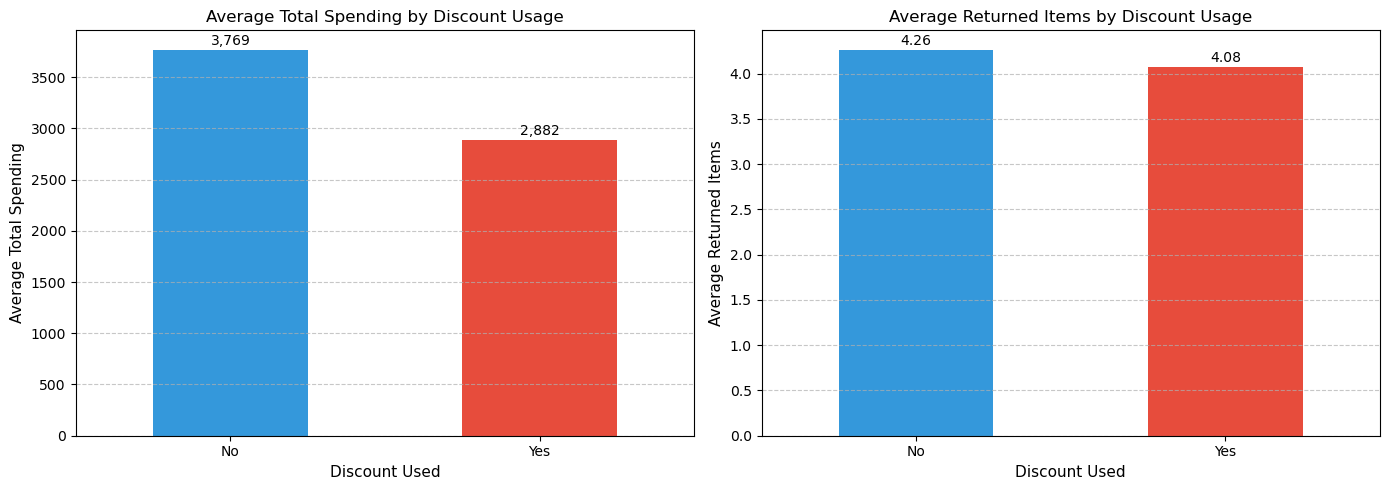

In [86]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Average Spending by Discount
discount_comparison.plot(x="discount_used", y="avg_spending", kind="bar", ax=axes[0], legend=False, color=['#3498db', '#e74c3c'])
axes[0].set_title("Average Total Spending by Discount Usage", fontsize=12)
axes[0].set_xlabel("Discount Used", fontsize=11)
axes[0].set_ylabel("Average Total Spending", fontsize=11)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
for i, v in enumerate(discount_comparison["avg_spending"]):
    axes[0].text(i, v + 50, f"{v:,.0f}", ha='center', fontsize=10)

# Chart 2: Average Returns by Discount
discount_comparison.plot(x="discount_used", y="avg_returned", kind="bar", ax=axes[1], legend=False, color=['#3498db', '#e74c3c'])
axes[1].set_title("Average Returned Items by Discount Usage", fontsize=12)
axes[1].set_xlabel("Discount Used", fontsize=11)
axes[1].set_ylabel("Average Returned Items", fontsize=11)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
for i, v in enumerate(discount_comparison["avg_returned"]):
    axes[1].text(i, v + 0.05, f"{v:.2f}", ha='center', fontsize=10)

plt.tight_layout()
plt.savefig("charts/q5_discount_comparison.png", dpi=150)
plt.show()

### Device Analysis
The following table shows average total spending by device type.

In [89]:
device_stats = df.groupby("device")["total_spending"].agg(["count", "mean"]).reset_index()
device_stats = device_stats[device_stats["count"] >= 3]
device_stats = device_stats.sort_values("mean", ascending=False)

print("Device Statistics:")
print(device_stats.to_string(index=False))

Device Statistics:
 device  count        mean
 iPhone     18 3773.945000
Android     22 3508.268636
    Web     20 2897.760000


### Payment Method Analysis
The following table shows average total spending by payment method.

In [92]:
payment_stats = df.groupby("payment_method")["total_spending"].agg(["count", "mean"]).reset_index()
payment_stats = payment_stats[payment_stats["count"] >= 3]
payment_stats = payment_stats.sort_values("mean", ascending=False)

print("Payment Method Statistics:")
print(payment_stats.to_string(index=False))

Payment Method Statistics:
payment_method  count        mean
          Card     18 3929.005000
 Online Wallet     23 3151.522609
          Cash     19 3150.579474


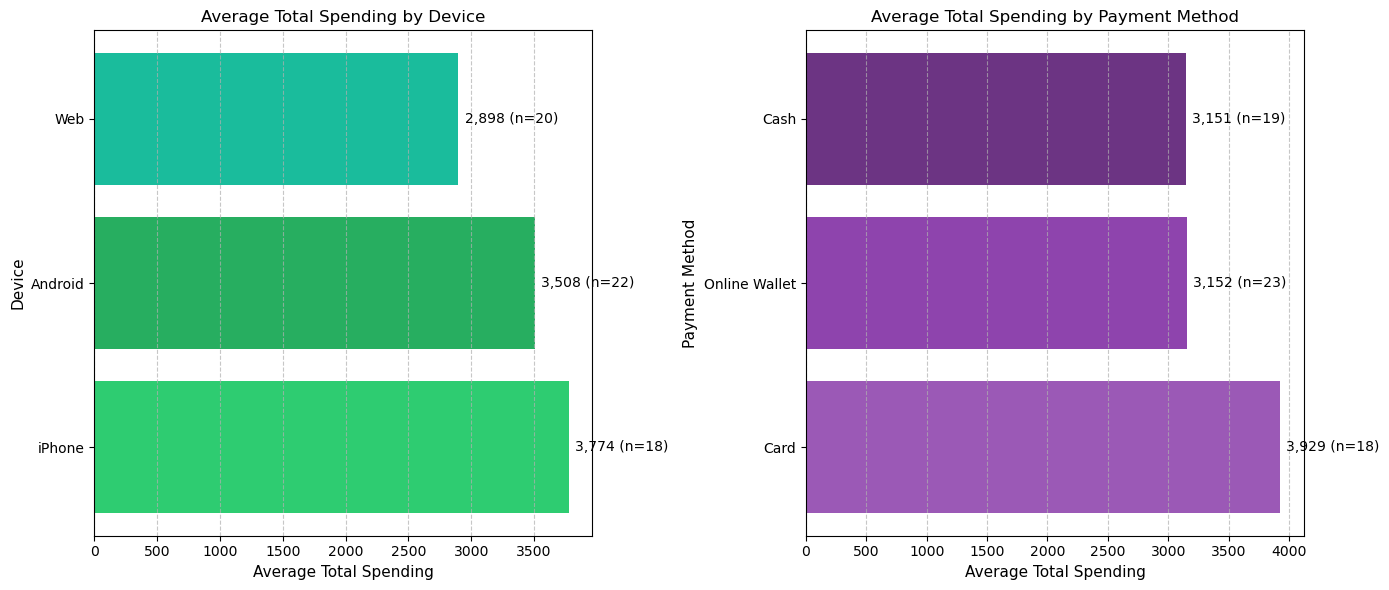

In [94]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1: Device
bars1 = axes[0].barh(device_stats["device"], device_stats["mean"], color=['#2ecc71', '#27ae60', '#1abc9c'])
axes[0].set_title("Average Total Spending by Device", fontsize=12)
axes[0].set_xlabel("Average Total Spending", fontsize=11)
axes[0].set_ylabel("Device", fontsize=11)
axes[0].grid(axis='x', linestyle='--', alpha=0.7)
for i, v in enumerate(device_stats["mean"]):
    axes[0].text(v + 50, i, f"{v:,.0f} (n={int(device_stats['count'].iloc[i])})", va='center', fontsize=10)

# Chart 2: Payment Method
bars2 = axes[1].barh(payment_stats["payment_method"], payment_stats["mean"], color=['#9b59b6', '#8e44ad', '#6c3483'])
axes[1].set_title("Average Total Spending by Payment Method", fontsize=12)
axes[1].set_xlabel("Average Total Spending", fontsize=11)
axes[1].set_ylabel("Payment Method", fontsize=11)
axes[1].grid(axis='x', linestyle='--', alpha=0.7)
for i, v in enumerate(payment_stats["mean"]):
    axes[1].text(v + 50, i, f"{v:,.0f} (n={int(payment_stats['count'].iloc[i])})", va='center', fontsize=10)

plt.tight_layout()
plt.savefig("charts/q5_device_payment_comparison.png", dpi=150)
plt.show()

## Question 5: How Do Discount, Device, and Payment Method Relate to Customer Behavior?

This section analyzes the descriptive relationship between:
1. Discount usage and customer spending/returns
2. Device type and customer spending
3. Payment method and customer spending

**Important:** All findings are descriptive only. This analysis does not prove causation.

---

### 1. Discount Usage Comparison

| Discount Used | Count | Avg Spending | Avg Purchase Count | Avg Order Value | Avg Returned | Avg Satisfaction |
|---------------|-------|--------------|--------------------|-----------------|--------------|------------------|
| No            | 34    | 3,768.58     | 17.79              | 220.70          | 4.26         | 2.76             |
| Yes           | 26    | 2,882.17     | 17.50              | 203.29          | 4.08         | 3.27             |

**Key Observations:**

- **Spending:** Customers who did NOT use discounts have **higher** average total spending (3,768.58) compared to discount users (2,882.17).
- **Returns:** Returned items are nearly identical between both groups (4.26 vs 4.08).
- **Satisfaction:** Discount users report **higher** satisfaction (3.27 vs 2.76), suggesting discounts may improve customer experience.
- **Sample Size:** Both groups have sufficient sample sizes (34 and 26) for comparison.

---


### 2. Device Analysis

| Device   | Count | Avg Spending |
|----------|-------|--------------|
| iPhone   | 18    | 3,773.95     |
| Android  | 22    | 3,508.27     |
| Web      | 20    | 2,897.76     |

**Key Observations:**

- **Highest Spending:** iPhone users have the highest average spending (3,773.95).
- **Lowest Spending:** Web users have the lowest average spending (2,897.76).
- **Sample Sizes:** All groups have sufficient sample sizes (18–22 customers).
- **Implication:** Mobile users (especially iPhone) appear to be more valuable than web users.

---

### 3. Payment Method Analysis

| Payment Method | Count | Avg Spending |
|----------------|-------|--------------|
| Card           | 18    | 3,929.01     |
| Online Wallet  | 23    | 3,151.52     |
| Cash           | 19    | 3,150.58     |

**Key Observations:**

- **Highest Spending:** Card users have the highest average spending (3,929.01).
- **Lowest Spending:** Cash and Online Wallet users have nearly identical average spending (~3,150).
- **Sample Sizes:** All groups have sufficient sample sizes (18–23 customers).
- **Implication:** Encouraging card payments may correlate with higher customer spending.

---

### Descriptive Summary Table

| Factor           | Highest Avg Spending | Lowest Avg Spending | Sample Size Reliable? |
|------------------|----------------------|---------------------|------------------------|
| **Discount**     | No Discount (3,768)  | Discount (2,882)    | Yes                    |
| **Device**       | iPhone (3,774)       | Web (2,898)         | Yes                    |
| **Payment Method** | Card (3,929)       | Cash (3,151)        | Yes                    |

---

### Key Takeaways

1. **Discount:** Customers who do not use discounts spend more on average, but discount users report higher satisfaction. This could mean discounts attract price-sensitive customers who spend less, or that discounts increase satisfaction without necessarily increasing spending.

2. **Device:** iPhone users are the most valuable customers by average spending. This may indicate that iOS users have higher purchasing power or a stronger brand affinity.

3. **Payment Method:** Card users have the highest average spending. This could suggest that credit/debit card users are more financially capable, or that card payments enable larger purchases compared to cash or wallet payments.

---

###  Important Disclaimer

> **This analysis is purely descriptive and does NOT establish causation.**
>
> Any observed differences between groups may be influenced by other factors such as:
> - Customer demographics (age, income, location)
> - Product preferences
> - Shopping habits and frequency
> - Seasonal trends or promotions
>
> To determine causal relationships, controlled experiments (e.g., A/B testing) or longitudinal data would be required.



## Question 6: creating KPIs

In [107]:
kpi_data = {
    "KPI": [
        "Total Unique Customers",
        "Total Revenue",
        "Average Satisfaction Score",
        "Average Purchase Count per Customer",
        "At-Risk Customers",
        "Top City by Revenue"
    ],
    "Value": [
        len(df["customer_id"].unique()),
        f"{df['total_spending'].sum():,.2f}",
        f"{df['satisfaction_score'].mean():.2f}",
        f"{df['purchase_count'].mean():.2f}",
        len(at_risk_customers),
        final_ranking.iloc[0]["city"] + " (" + final_ranking.iloc[0]["province"] + ")"
    ]
}

kpi_df = pd.DataFrame(kpi_data)
print("=" * 60)
print("KPI Summary Table")
print("=" * 60)
print(kpi_df.to_string(index=False))

KPI Summary Table
                                KPI              Value
             Total Unique Customers                 60
                      Total Revenue         203,068.12
         Average Satisfaction Score               2.98
Average Purchase Count per Customer              17.67
                  At-Risk Customers                  1
                Top City by Revenue Mashhad (Khorasan)


## Question 6: 5-Minute Executive Report

This section provides a concise executive summary of the business status, key opportunities, and key risks based on the complete analysis.

---

### 1. Key Performance Indicators (KPIs)

| KPI | Value |
|-----|-------|
| Total Unique Customers | 60 |
| Total Revenue | 203,068.12 IRR |
| Average Satisfaction Score | 2.98 / 5 |
| Average Purchase Count per Customer | 17.67 |
| At-Risk Customers | 1 |
| Top City by Revenue | Mashhad (Khorasan) |

---

### 2. Selected Visualizations

#### Chart 1: Total Revenue by City (Opportunity)

![City Revenue](charts/q2_city_revenue.png)

**Why this chart:** Mashhad is the highest-revenue city (43,197 IRR) with 11 customers. This represents the greatest growth opportunity, but requires careful quality management due to below-average satisfaction (2.91).

---

#### Chart 2: At-Risk Customers (Risk)

![At-Risk Customers](charts/q4_at_risk_customers.png)

**Why this chart:** Identifies high-value customers who have become inactive. One customer (Arash, 5,918 IRR, 365 days inactive) is flagged as the primary churn risk.

---

#### Chart 3: Membership Tier Distribution (Customer Composition)

![Membership Tiers](charts/q1_customer_persona.png)

**Why this chart:** Reveals that current membership tiers do not align with actual customer loyalty scores. The highest-loyalty customer (Maryam, score 0.86) holds only a Bronze tier, while some Gold/VIP customers scored lower.

---

### 3. Executive Recommendations

#### Recommendation 1: Quality Control & Satisfaction Monitoring in Mashhad

| KPI | Action | Evidence |
|-----|--------|----------|
| **Total Revenue:** 43,197.58 IRR (highest) | Launch a **3-question satisfaction survey** for Mashhad customers to identify root causes of low satisfaction (2.91) | Mashhad generates the highest revenue but has below-average satisfaction. Investing in quality control now prevents customer churn and protects future revenue. |

**Why this matters:** Acquiring new customers is expensive. If new customers in Mashhad have a poor experience, they will not return and may discourage others. Prevention is cheaper than re-acquisition.

---

#### Recommendation 2: Revise the Membership Tier System

| KPI | Action | Evidence |
|-----|--------|----------|
| **Loyalty Score** (calculated in Question 3) | Redefine membership criteria based on actual customer value; automatically upgrade high-loyalty customers | Maryam (loyalty score 0.86, #1) holds a Bronze tier, while some Gold/VIP customers have lower scores. Current tiers do not reflect actual customer value. |

**Why this matters:** Customers like Maryam may feel undervalued and disengage. A fair, transparent tier system based on real value will improve retention and motivation.

---

#### Recommendation 3: Smart Discount Strategy for Inactive Customers

| KPI | Action | Evidence |
|-----|--------|----------|
| **At-Risk Customers:** 1 (Arash, 5,918 IRR, 365 days inactive) | **Tier 1:** 5% discount for all customers inactive >6 months<br>**Tier 2:** 15% personalized discount + personal message for high-value customers like Arash | Arash was a top-spending customer (top 25%) but hasn't purchased in 365 days. His satisfaction is average (3/5), suggesting disengagement, not dissatisfaction. A personalized offer can bring him back. |

**Why this matters:** Small discounts for all inactive customers show that the brand cares. Larger, personalized discounts for high-value customers make them feel special and valued. This dual strategy maximizes ROI.

---

### Summary Dashboard

| Aspect | Finding | Recommended Action |
|--------|---------|---------------------|
| **Opportunity** | Mashhad is the highest-revenue city | Launch satisfaction survey + quality control |
| **Risk** | 1 high-value customer is at risk of churn | Send personalized win-back offer (15% discount) |
| **Customer Strategy** | Membership tiers misaligned with loyalty scores | Revise tier criteria and upgrade high-loyalty customers |

---

### Important Limitations

> - The dataset contains only 60 customers, so some findings may not be statistically significant.
> - Last purchase days are available, but complete order history is not, so churn cannot be definitively confirmed.
> - Discount analysis is descriptive only and does not prove causation.
> - Recommendations are based on patterns observed in the available data and should be validated with further analysis.

---

### Final Note

All three recommendations are:
- **Data-driven** (supported by specific KPIs and evidence)
- **Actionable** (clear, measurable next steps)
- **Aligned with business priorities** (growth, retention, and customer satisfaction)